In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from prism.prism_math.activation_coefs import get_alpha_coefs, compute_eta_error_tanh
from prism.prism_math.polynomials import polyval_cpu


In [2]:
alpha_coefs, exponents, alpha_coefs_float64 = get_alpha_coefs(
    function_type='relu',
    big_m=10, v_max=2, dps=64,
    load_file=None, save=False, silent=True)

In [3]:
from mpmath import cos, exp, fabs, betainc, csch, factorial, fmul, gamma, \
    hyper, im, lerchphi, meijerg, polar, re, rect, sech, sqrt, sign, si, sin, tanh
from mpmath import mp
from mpmath import pi, inf, j
from mpmath import quad

mp.dps = 100

In [4]:
def compute_eta_error_relu2(v_values, big_m, v_max):
    q = 2*big_m + 2
    sigma = (factorial(q)) ** (1/q) / v_max

    eta_error_relu = np.zeros(v_values.shape)

    for idx in range(0, len(v_values)):
        v = v_values[idx]

        integrand1 = lambda xi: \
            xi**(2*big_m) * hyper([1], [big_m+2, big_m+3/2], -(xi*v)**2.0/4.0)
        integral1 = quad(integrand1, [0, sigma])

        integrand2 = lambda xi: cos(xi*v) / (xi ** 2)
        integral2 = quad(integrand2, [sigma, inf])

        eta_error_relu[idx] = \
            (-1)**big_m * v**(2*big_m + 2) / (pi*factorial(2*big_m+2)) * integral1 \
            - 1/pi*re(integral2)

    return eta_error_relu

In [5]:
def compute_eta_error_relu3(v_values, big_m, v_max):
    q = 2*big_m + 2
    sigma = (factorial(q)) ** (1/q) / v_max

    eta_error_relu = np.zeros(v_values.shape)

    for idx in range(0, len(v_values)):
        v = v_values[idx]

        term1 = (-1)**big_m * sigma**(2*big_m + 1) * v**(2*big_m + 2) \
            / (pi*factorial(2*big_m+2)*(2*big_m + 1)) \
            * hyper([1, big_m + 1/2], [big_m+3/2, big_m+3/2, big_m+2], -(sigma*v)**2.0/4.0)

        term2 = abs(v)/2 - v*si(sigma*v)/pi - cos(sigma*v)/(sigma*pi)

        eta_error_relu[idx] = term1 + term2

    return eta_error_relu

In [6]:
def compute_eta_error_approx(v_values, big_m, v_max):
    q = 2*big_m + 2
    sigma = (factorial(q)) ** (1/q) / v_max

    eta_error_relu = np.zeros(v_values.shape)

    for idx in range(0, len(v_values)):
        v = v_values[idx]
        term2 = abs(v)/2 - v*si(sigma*v)/pi - cos(sigma*v)/(sigma*pi)
        eta_error_relu[idx] = term2

    return eta_error_relu

In [7]:
v = np.arange(-2.1, 2.1, 0.1)
y = polyval_cpu(alpha_coefs_float64, exponents, v)
y_true = np.abs(v)/2 + v/2

In [8]:
error_true = y_true - y
error1 = compute_eta_error_relu2(v, big_m=10, v_max=2)
error2 = compute_eta_error_relu3(v, big_m=10, v_max=2)
errora = compute_eta_error_approx(v, big_m=10, v_max=2)

Text(0, 0.5, 'log10(abs(coef))')

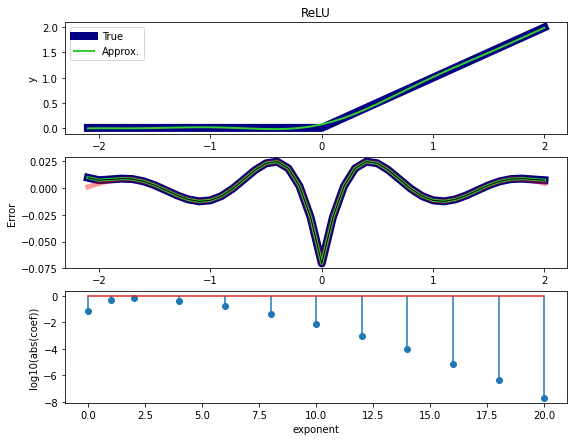

In [11]:
fig, axs = plt.subplots(3, 1, figsize=(9,7))
axs[0].plot(v, y_true, linewidth=8, color='navy')
axs[0].plot(v, y, linewidth=2, color='limegreen')
axs[0].set_xlabel('v')
axs[0].set_ylabel('y')
axs[0].set_title('ReLU')
axs[0].legend(('True', 'Approx.'))
axs[1].plot(v, error_true, linewidth=8, color='navy')
axs[1].plot(v, errora, linewidth=5, color='r', alpha=0.4)
axs[1].plot(v, error1, linewidth=3, color='limegreen')
axs[1].plot(v, error2, linewidth=1, color='black')
axs[1].set_xlabel('v')
axs[1].set_ylabel('Error')
axs[2].stem(exponents, np.log10(np.abs(alpha_coefs_float64)))
axs[2].set_xlabel('exponent')
axs[2].set_ylabel('log10(abs(coef))')

In [10]:
print(exponents)

[0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 1.0]
